# Human Activity Recognition using Deep Learning

## Objective

This notebook trains and compares multiple deep learning architectures for Human Activity Recognition (HAR) using the UCI HAR Dataset.

Models evaluated:

- Dense Neural Network
- Simple RNN
- LSTM
- GRU
- 1D CNN
- CNN-LSTM Hybrid

The best-performing model will later be deployed in a Streamlit application.

## Imports

In [1]:
from pathlib import Path

import pandas as pd

from src.data_loader import load_dataset
from src.preprocessing import encode_labels

from src.models import (
    build_dense,
    build_rnn,
    build_lstm,
    build_gru,
    build_cnn,
    build_cnn_lstm
)

from src.trainer import train_model

from src.utils import (
    set_seed,
    CLASS_NAMES
)

2026-08-10 11:10:14.319791: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-10 11:10:14.612265: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786342214.702068     553 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786342214.730198     553 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1786342214.973787     553 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Configuration

In [2]:
set_seed(42)

DATASET_PATH = Path("../data/UCI HAR Dataset")

## Load Dataset

In [3]:
X_train, X_test, y_train, y_test = load_dataset(DATASET_PATH)

print(f"Training Shape : {X_train.shape}")
print(f"Testing Shape  : {X_test.shape}")

Training Shape : (7352, 128, 9)
Testing Shape  : (2947, 128, 9)


## Encode Labels

In [4]:
y_train, y_test = encode_labels(
    y_train,
    y_test
)

print(y_train.shape)
print(y_test.shape)

(7352, 6)
(2947, 6)


In [5]:
import os
import pandas as pd
import numpy as np

# X_test is your test tensor with shape (2947, 128, 9)
# y_test is one-hot encoded
# CLASS_NAMES = [...]

CLASS_NAMES = [
    "Walking",
    "Walking Upstairs",
    "Walking Downstairs",
    "Sitting",
    "Standing",
    "Laying"
]

output_dir = "../app/sample_data"
os.makedirs(output_dir, exist_ok=True)

saved = set()

for i in range(len(X_test)):

    label = CLASS_NAMES[np.argmax(y_test[i])]

    filename = label.lower().replace(" ", "_") + ".csv"

    if filename in saved:
        continue

    df = pd.DataFrame(
        X_test[i],
        columns=[
            "Body Acc X",
            "Body Acc Y",
            "Body Acc Z",
            "Body Gyro X",
            "Body Gyro Y",
            "Body Gyro Z",
            "Total Acc X",
            "Total Acc Y",
            "Total Acc Z",
        ],
    )

    df.to_csv(
        os.path.join(output_dir, filename),
        index=False,
        header=False,
    )

    saved.add(filename)

    if len(saved) == 6:
        break

print("Sample CSV files created successfully!")

Sample CSV files created successfully!


## Training the Models

In [5]:
MODELS = {
    "Dense": build_dense,
    "Simple RNN": build_rnn,
    "LSTM": build_lstm,
    "GRU": build_gru,
    "CNN": build_cnn,
    "CNN-LSTM": build_cnn_lstm,
}

I0000 00:00:1786020255.705694   36091 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1414 MB memory:  -> device: 0, name: NVIDIA GeForce MX330, pci bus id: 0000:01:00.0, compute capability: 6.1



Training Dense
Epoch 1/100


I0000 00:00:1786020257.372249   36148 service.cc:152] XLA service 0x72064c00ba80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786020257.372303   36148 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce MX330, Compute Capability 6.1
2026-08-06 17:44:17.396655: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786020257.554064   36148 cuda_dnn.cc:529] Loaded cuDNN version 90300


 47/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5731 - loss: 1.0296

I0000 00:00:1786020259.792823   36148 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7504 - loss: 0.6398 - val_accuracy: 0.8409 - val_loss: 0.5045
Epoch 2/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9009 - loss: 0.2686 - val_accuracy: 0.8654 - val_loss: 0.5370
Epoch 3/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9271 - loss: 0.1773 - val_accuracy: 0.8878 - val_loss: 0.5146
Epoch 4/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9327 - loss: 0.1752 - val_accuracy: 0.8790 - val_loss: 0.4830
Epoch 5/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9437 - loss: 0.1389 - val_accuracy: 0.8763 - val_loss: 0.7367
Epoch 6/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9427 - loss: 0.1403 - val_accuracy: 0.9041 - val_loss: 0.4838
Epoch 7/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9476 - loss: 0.1301 - val_accuracy: 0.8858 - val_loss: 0.5613
Epoch 8/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9503 - loss: 0.1107 - val_accuracy: 0.879

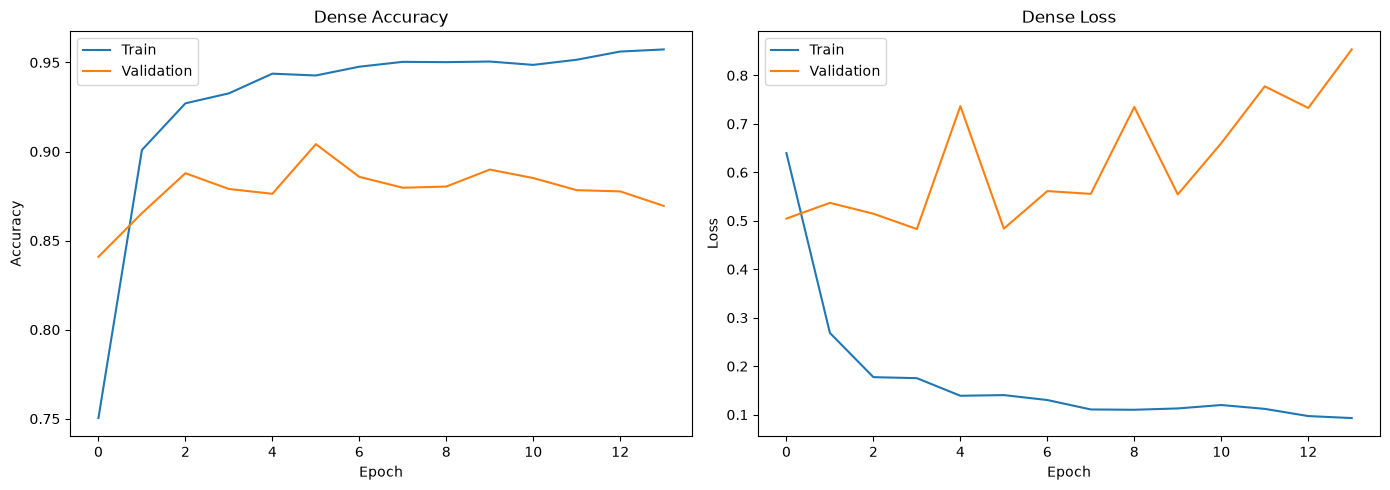


Dense
Accuracy : 0.8901
Precision: 0.8956
Recall   : 0.8901
F1 Score : 0.8895

                    precision    recall  f1-score   support

           Walking       0.99      0.83      0.90       496
  Walking Upstairs       0.82      0.94      0.88       471
Walking Downstairs       0.85      0.95      0.89       420
           Sitting       0.89      0.75      0.81       491
          Standing       0.82      0.87      0.85       532
            Laying       0.99      1.00      1.00       537

          accuracy                           0.89      2947
         macro avg       0.89      0.89      0.89      2947
      weighted avg       0.90      0.89      0.89      2947



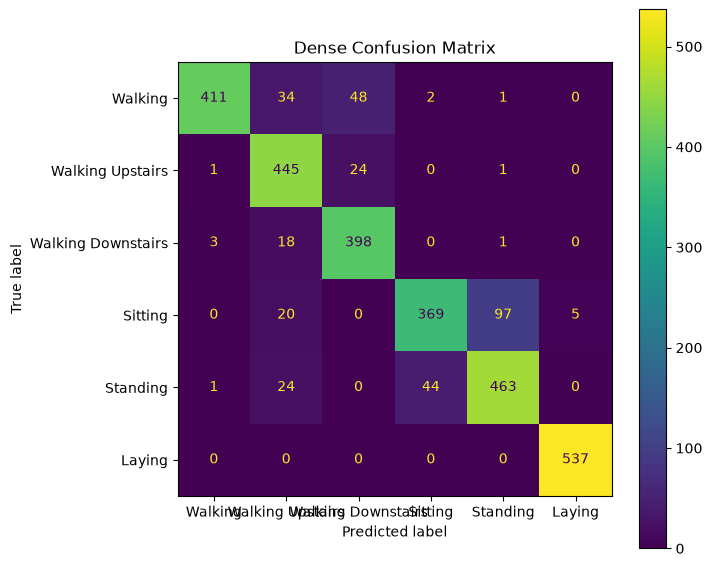


Training Simple RNN
Epoch 1/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.5037 - loss: 1.1243 - val_accuracy: 0.6166 - val_loss: 0.8804
Epoch 2/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6290 - loss: 0.8249 - val_accuracy: 0.6574 - val_loss: 0.8122
Epoch 3/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6286 - loss: 0.8244 - val_accuracy: 0.6105 - val_loss: 1.1024
Epoch 4/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6599 - loss: 0.7516 - val_accuracy: 0.6390 - val_loss: 0.9101
Epoch 5/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7016 - loss: 0.6359 - val_accuracy: 0.7213 - val_loss: 0.7151
Epoch 6/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6943 - loss: 0.7074 - val_accuracy: 0.7111 - val_loss: 0.8112
Epoch 7/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7006 - loss: 0.6736 - val_accuracy: 0.5812 - val_loss: 1.1137
Epoch 8/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.

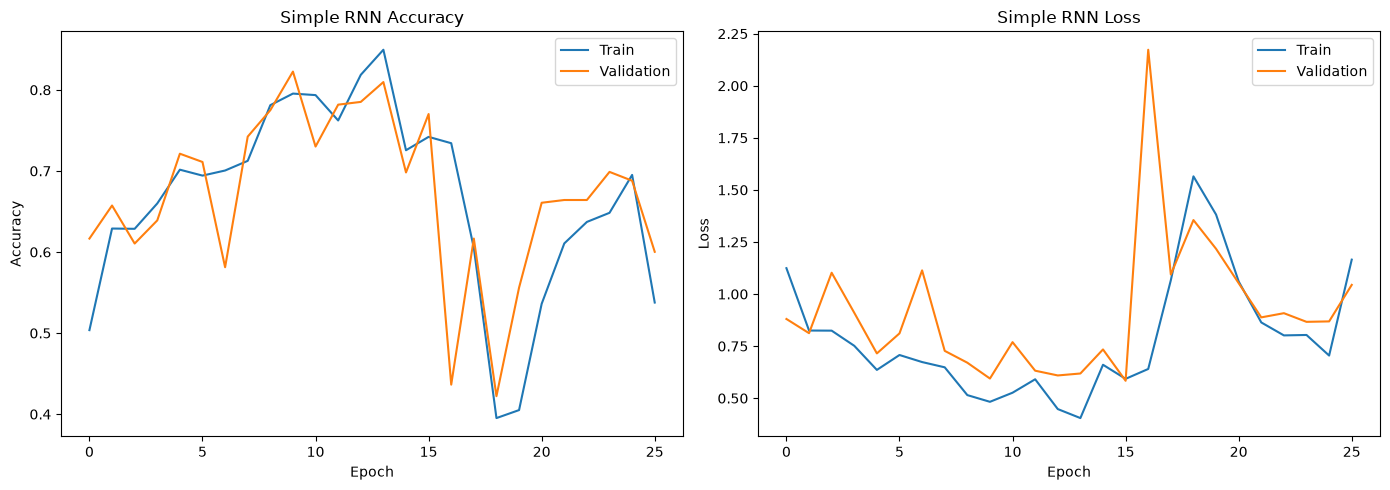


Simple RNN
Accuracy : 0.7272
Precision: 0.7632
Recall   : 0.7272
F1 Score : 0.7228

                    precision    recall  f1-score   support

           Walking       0.49      0.89      0.63       496
  Walking Upstairs       0.79      0.44      0.56       471
Walking Downstairs       0.66      0.40      0.50       420
           Sitting       0.82      0.76      0.79       491
          Standing       0.79      0.83      0.81       532
            Laying       1.00      0.95      0.97       537

          accuracy                           0.73      2947
         macro avg       0.76      0.71      0.71      2947
      weighted avg       0.76      0.73      0.72      2947



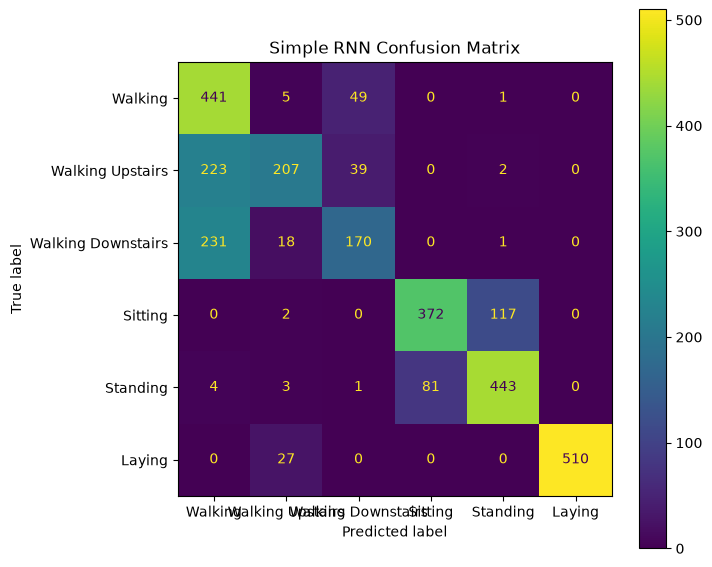


Training LSTM
Epoch 1/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.5069 - loss: 1.1482 - val_accuracy: 0.4901 - val_loss: 1.1554
Epoch 2/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.6019 - loss: 0.9110 - val_accuracy: 0.6506 - val_loss: 0.8635
Epoch 3/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.5621 - loss: 1.0108 - val_accuracy: 0.6179 - val_loss: 1.0523
Epoch 4/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.6723 - loss: 0.7905 - val_accuracy: 0.6717 - val_loss: 0.8795
Epoch 5/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.7681 - loss: 0.5452 - val_accuracy: 0.7818 - val_loss: 0.7018
Epoch 6/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.8747 - loss: 0.3759 - val_accuracy: 0.8715 - val_loss: 0.4950
Epoch 7/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9102 - loss: 0.2570 - val_accuracy: 0.8797 - val_loss: 0.4435
Epoch 8/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9265 - 

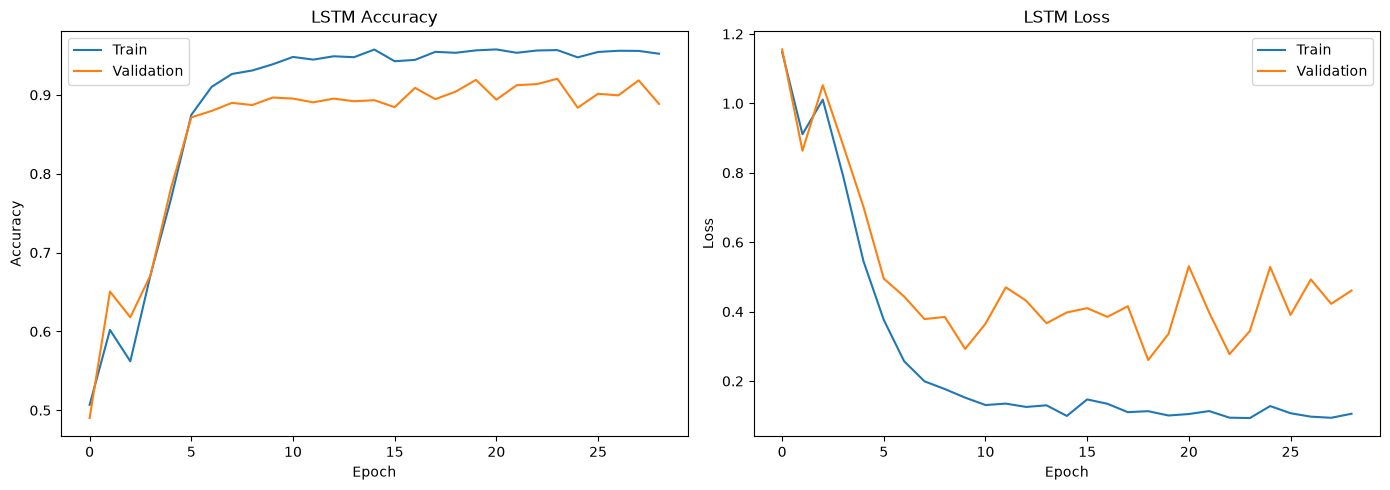


LSTM
Accuracy : 0.9186
Precision: 0.9207
Recall   : 0.9186
F1 Score : 0.9173

                    precision    recall  f1-score   support

           Walking       0.99      0.91      0.95       496
  Walking Upstairs       0.91      0.97      0.94       471
Walking Downstairs       0.92      1.00      0.96       420
           Sitting       0.89      0.73      0.80       491
          Standing       0.82      0.91      0.86       532
            Laying       1.00      1.00      1.00       537

          accuracy                           0.92      2947
         macro avg       0.92      0.92      0.92      2947
      weighted avg       0.92      0.92      0.92      2947



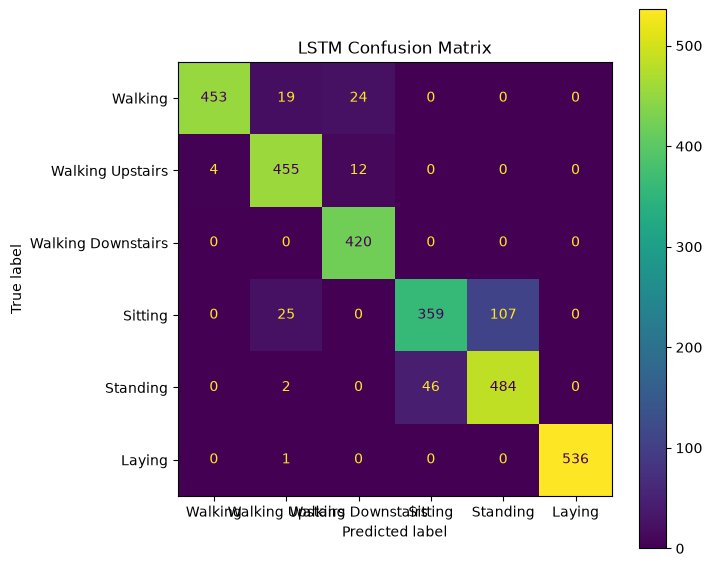


Training GRU
Epoch 1/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.5385 - loss: 1.1108 - val_accuracy: 0.6825 - val_loss: 0.8628
Epoch 2/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.7698 - loss: 0.5553 - val_accuracy: 0.8158 - val_loss: 0.5080
Epoch 3/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9068 - loss: 0.2517 - val_accuracy: 0.7967 - val_loss: 0.5521
Epoch 4/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.9361 - loss: 0.1753 - val_accuracy: 0.9164 - val_loss: 0.2375
Epoch 5/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9412 - loss: 0.1483 - val_accuracy: 0.9048 - val_loss: 0.3662
Epoch 6/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.9391 - loss: 0.1545 - val_accuracy: 0.8967 - val_loss: 0.3620
Epoch 7/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.9502 - loss: 0.1201 - val_accuracy: 0.9205 - val_loss: 0.2972
Epoch 8/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9483 - l

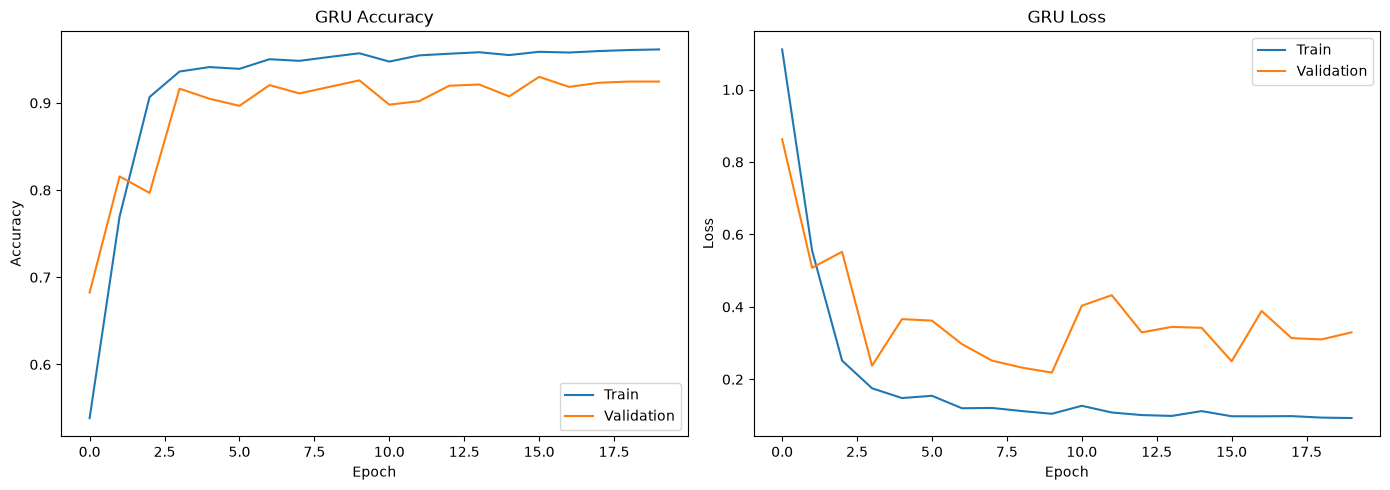


GRU
Accuracy : 0.9043
Precision: 0.9063
Recall   : 0.9043
F1 Score : 0.9043

                    precision    recall  f1-score   support

           Walking       0.98      0.91      0.94       496
  Walking Upstairs       0.89      0.97      0.93       471
Walking Downstairs       0.93      0.98      0.95       420
           Sitting       0.83      0.77      0.80       491
          Standing       0.80      0.85      0.83       532
            Laying       1.00      0.95      0.97       537

          accuracy                           0.90      2947
         macro avg       0.91      0.91      0.91      2947
      weighted avg       0.91      0.90      0.90      2947



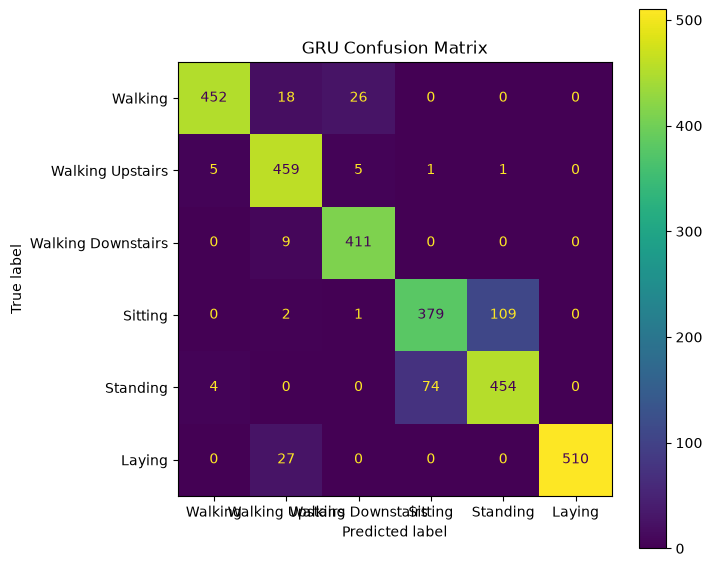


Training CNN
Epoch 1/100


2026-08-06 17:51:38.600542: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.54GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


176/184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7010 - loss: 0.7703

2026-08-06 17:51:42.745993: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.43GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.7072 - loss: 0.7550 - val_accuracy: 0.8504 - val_loss: 0.4286
Epoch 2/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9000 - loss: 0.2738 - val_accuracy: 0.8987 - val_loss: 0.3047
Epoch 3/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9374 - loss: 0.1668 - val_accuracy: 0.9035 - val_loss: 0.3195
Epoch 4/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9459 - loss: 0.1353 - val_accuracy: 0.9028 - val_loss: 0.3216
Epoch 5/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9517 - loss: 0.1201 - val_accuracy: 0.9048 - val_loss: 0.3507
Epoch 6/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9520 - loss: 0.1084 - val_accuracy: 0.9157 - val_loss: 0.3717
Epoch 7/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9553 - loss: 0.1003 - val_accuracy: 0.9069 - val_loss: 0.3788
Epoch 8/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9558 - loss: 0.1021 - val_accuracy: 0.

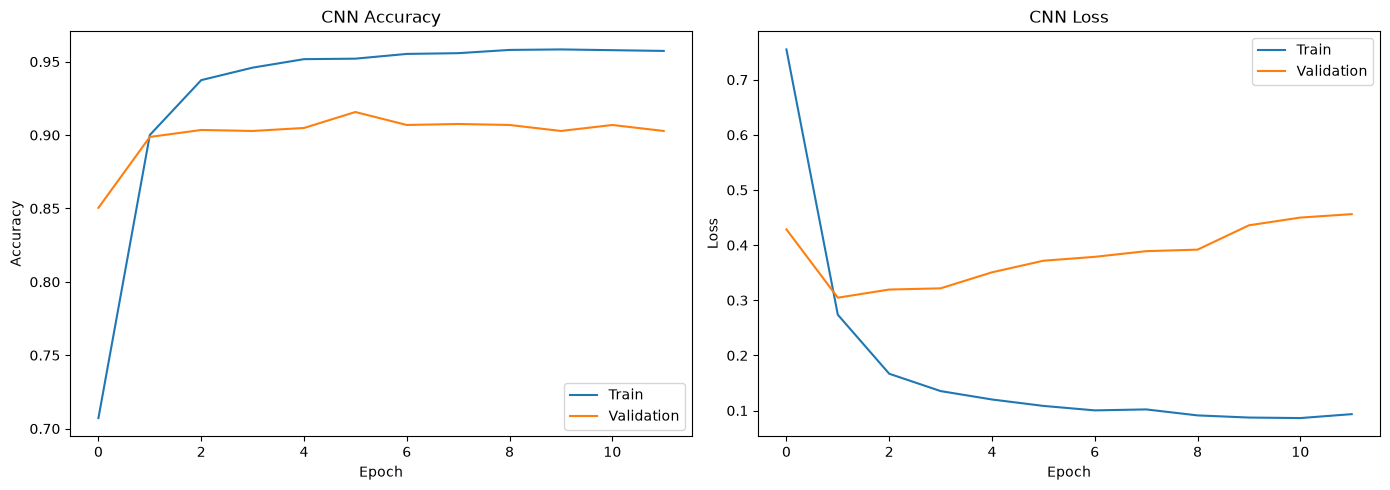


CNN
Accuracy : 0.8860
Precision: 0.8899
Recall   : 0.8860
F1 Score : 0.8863

                    precision    recall  f1-score   support

           Walking       0.93      0.89      0.91       496
  Walking Upstairs       0.87      0.89      0.88       471
Walking Downstairs       0.80      0.94      0.86       420
           Sitting       0.87      0.78      0.82       491
          Standing       0.84      0.89      0.86       532
            Laying       1.00      0.94      0.97       537

          accuracy                           0.89      2947
         macro avg       0.89      0.89      0.88      2947
      weighted avg       0.89      0.89      0.89      2947



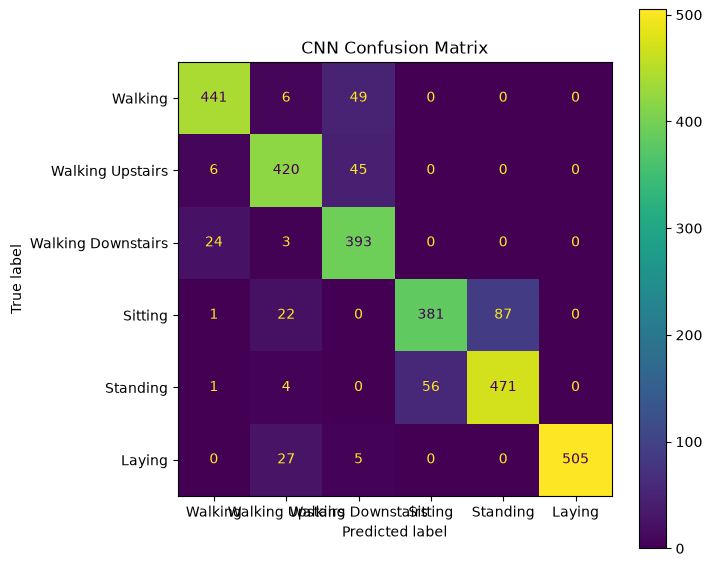


Training CNN-LSTM
Epoch 1/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.6696 - loss: 0.8084 - val_accuracy: 0.8110 - val_loss: 0.5797
Epoch 2/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.8730 - loss: 0.3568 - val_accuracy: 0.8722 - val_loss: 0.3979
Epoch 3/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9305 - loss: 0.2002 - val_accuracy: 0.9014 - val_loss: 0.3559
Epoch 4/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9407 - loss: 0.1597 - val_accuracy: 0.8899 - val_loss: 0.4248
Epoch 5/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9458 - loss: 0.1435 - val_accuracy: 0.9055 - val_loss: 0.3694
Epoch 6/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9456 - loss: 0.1372 - val_accuracy: 0.8783 - val_loss: 0.4211
Epoch 7/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9376 - loss: 0.1664 - val_accuracy: 0.8912 - val_loss: 0.4441
Epoch 8/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.951

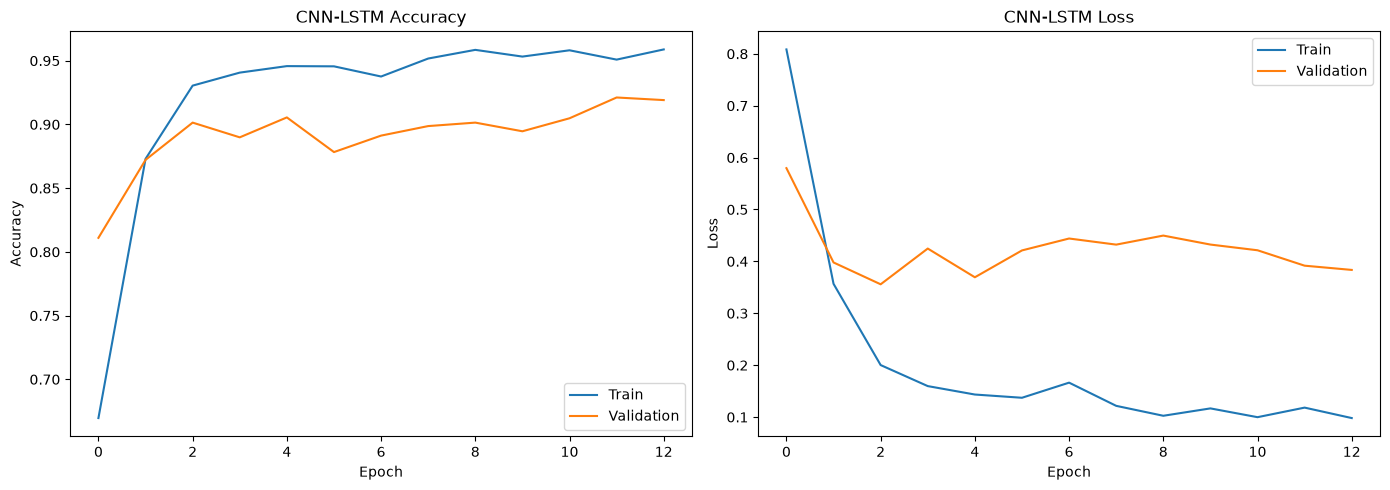


CNN-LSTM
Accuracy : 0.8833
Precision: 0.8854
Recall   : 0.8833
F1 Score : 0.8833

                    precision    recall  f1-score   support

           Walking       0.89      0.94      0.91       496
  Walking Upstairs       0.89      0.84      0.87       471
Walking Downstairs       0.86      0.94      0.90       420
           Sitting       0.79      0.85      0.82       491
          Standing       0.86      0.79      0.82       532
            Laying       1.00      0.95      0.97       537

          accuracy                           0.88      2947
         macro avg       0.88      0.88      0.88      2947
      weighted avg       0.89      0.88      0.88      2947



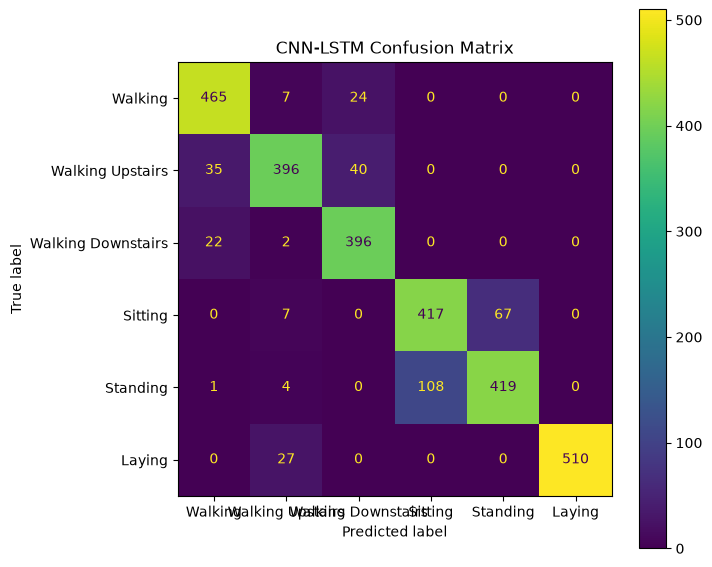

In [6]:
results = []
histories = {}

for model_name, builder in MODELS.items():

    history, metrics = train_model(
        model=builder(),
        model_name=model_name,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        class_names=CLASS_NAMES,
    )

    histories[model_name] = history
    results.append(metrics)

## Results

In [7]:
results_df = (
    pd.DataFrame(results)
      .sort_values("Accuracy", ascending=False)
      .reset_index(drop=True)
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,Parameters,Epochs,Training Time (s)
0,LSTM,0.918561,0.920705,0.918561,0.917309,79302,29,181.12
1,GRU,0.904309,0.906309,0.904309,0.904252,62022,20,118.18
2,Dense,0.890058,0.895571,0.890058,0.889471,755334,14,18.16
3,CNN,0.885986,0.889881,0.885986,0.886338,36294,12,25.93
4,CNN-LSTM,0.883271,0.885389,0.883271,0.883251,40518,13,65.73
5,Simple RNN,0.727180,0.763211,0.727180,0.722811,26310,26,115.10


## Save Results

In [8]:
results_df.to_csv(
    "../results/model_comparison.csv",
    index=False
)

## Observations

- Dense achieved competitive performance despite ignoring temporal information.
- Simple RNN performed considerably worse due to the vanishing gradient problem.
- LSTM and GRU effectively modeled temporal dependencies.
- CNN achieved similar accuracy with fewer parameters.
- CNN-LSTM combined convolutional feature extraction with sequence modeling.

## Best model

In [9]:
best_model = results_df.iloc[0]

best_model

Model                    LSTM
Accuracy             0.918561
Precision            0.920705
Recall               0.918561
F1 Score             0.917309
Parameters              79302
Epochs                     29
Training Time (s)      181.12
Name: 0, dtype: object

In [11]:
best_model_name = best_model["Model"]

print(f"Best Model: {best_model_name}")

Best Model: LSTM


In [12]:
MODEL_FILES = {
    "Dense": "Dense.keras",
    "Simple RNN": "Simple RNN.keras",
    "LSTM": "LSTM.keras",
    "GRU": "GRU.keras",
    "CNN": "CNN.keras",
    "CNN-LSTM": "CNN-LSTM.keras",
}

In [13]:
from pathlib import Path
import shutil

source = Path("../models") / MODEL_FILES[best_model_name]
destination = Path("../models") / "best_model.keras"

shutil.copy(source, destination)

PosixPath('../models/best_model.keras')